# Assay homogeneity
How similar are the compounds in a single assays.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from multiprocessing import Pool
import tqdm.auto as tqdm
from functools import namedtuple

import dti.data as dat
import dti.constants as const
from dti.utils import compute_fp

In [2]:
d = dat.load_landrum("../data/raw/omnivore.csv")

In [3]:
def add_fp_col(d: pd.DataFrame):
    with Pool(6) as p:
        fps = p.map(compute_fp, tqdm.tqdm(d[const.SMILES].values))
    d["fp"] = fps
    d.dropna(subset=["fp"], inplace=True)
    assert not d["fp"].isna().any()

In [4]:
add_fp_col(d)

  0%|          | 0/838155 [00:00<?, ?it/s]

In [5]:
def assay_variability(d: pd.DataFrame) -> pd.DataFrame:
    if "fp" not in d.columns:
        add_fp_col(d)
    Row = namedtuple("Row", [const.ASSAY, "variability", "size"])
    rows = []
    for assay, g in tqdm.tqdm(d.groupby(const.ASSAY)):
        var = np.stack(g["fp"].values).var()
        rows.append(Row(assay, var, len(g)))

    return pd.DataFrame(rows)

In [6]:
df_var = assay_variability(d)

  0%|          | 0/54787 [00:00<?, ?it/s]

array([[<Axes: title={'center': 'variability'}>]], dtype=object)

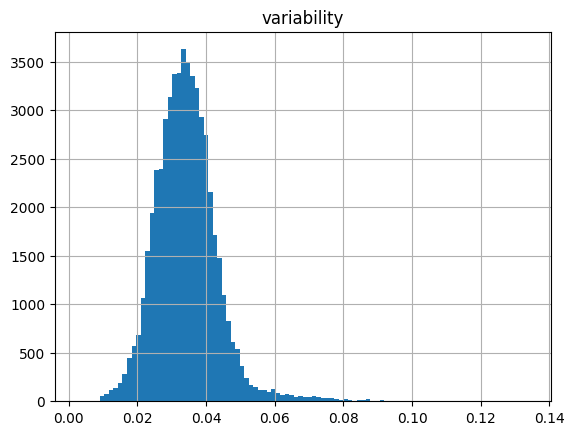

In [7]:
df_var[["variability"]].hist(bins=100)

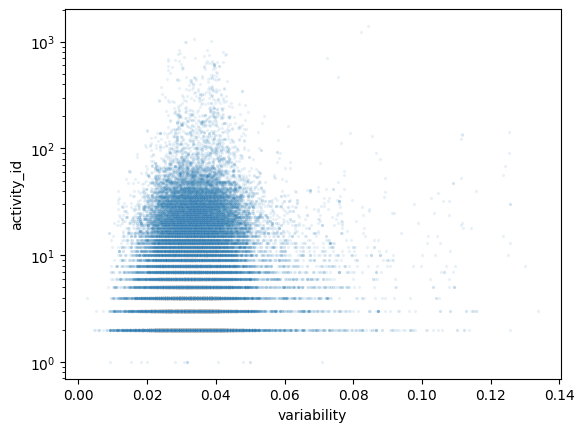

In [8]:
sns.scatterplot(
    d.groupby(const.ASSAY).count().join(df_var.set_index(const.ASSAY)),
    y="activity_id",
    x="variability",
    s=5,
    alpha=0.1,
)
plt.yscale("log")

In [9]:
df_var.set_index(const.ASSAY, inplace=True)

In [10]:
dp = pd.concat(
    [
        pd.read_csv(fname, index_col=0)
        for fname in [
            "../data/hpc-data/omnivore_0_sets_4e93/predictions.csv",
            "../data/hpc-data/omnivore_1_sets_8ec5/predictions.csv",
            "../data/hpc-data/omnivore_2_sets_47fb/predictions.csv",
            "../data/hpc-data/omnivore_3_sets_4bbc/predictions.csv",
            "../data/hpc-data/omnivore_4_sets_bb0e/predictions.csv",
        ]
    ]
)

In [11]:
for assay, g in tqdm.tqdm(dp.groupby(const.ASSAY)):
    df_var.loc[assay, "corr"] = (
        g[["prediction", "target"]].corr("spearman").values[1, 0]
    )

  0%|          | 0/45453 [00:00<?, ?it/s]

In [12]:
df_var.dropna(subset=["corr"], inplace=True)

In [13]:
df_var["log_size"] = np.log(df_var["size"])

In [14]:
df_var["fisher_corr"] = np.atanh(df_var["corr"])

/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)


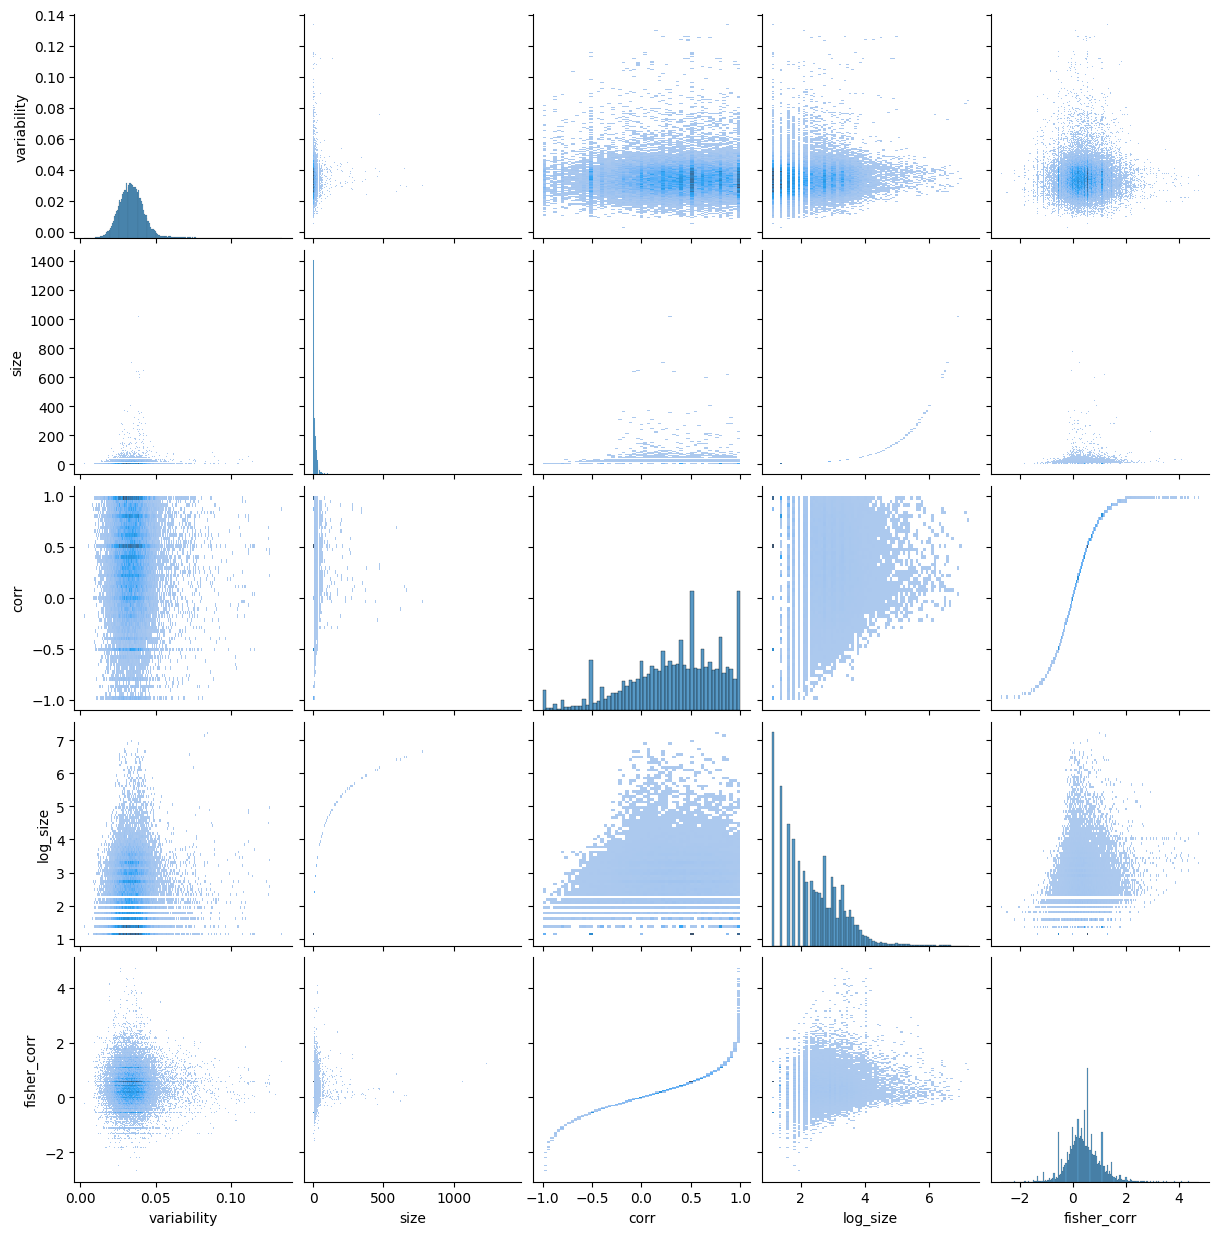

In [15]:
sns.pairplot(df_var, kind="hist")

In [16]:
df_var.corr("spearman")

,variability,size,corr,log_size,fisher_corr
variability,1.000000,0.067726,-0.001257,0.067726,0.008485
size,0.067726,1.000000,-0.063005,1.000000,0.040428
corr,-0.001257,-0.063005,1.000000,-0.063005,1.000000
log_size,0.067726,1.000000,-0.063005,1.000000,0.040428
fisher_corr,0.008485,0.040428,1.000000,0.040428,1.000000


<Axes: xlabel='fisher_corr', ylabel='Count'>

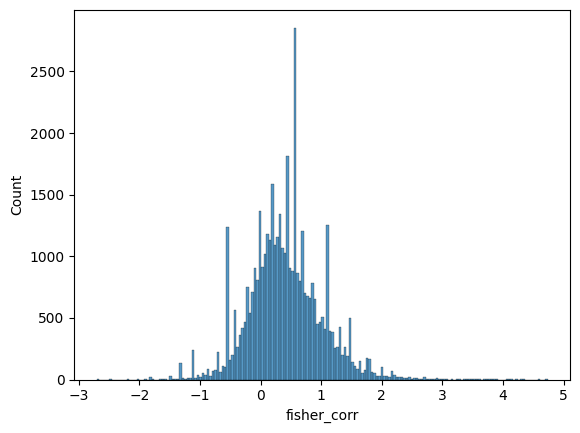

In [17]:
sns.histplot(df_var, x="fisher_corr", common_norm=True)

<Axes: xlabel='corr', ylabel='Count'>

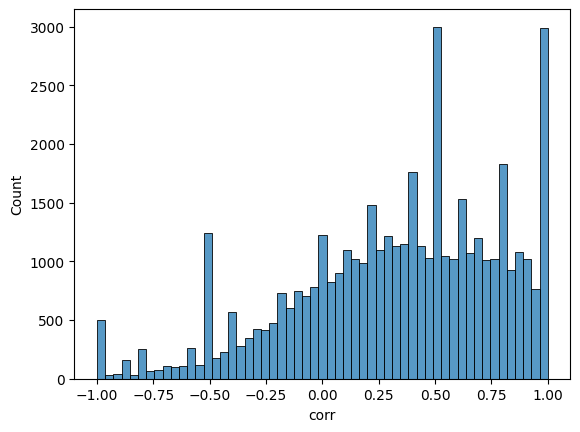

In [18]:
sns.histplot(df_var, x="corr", common_norm=True)

In [19]:
(df_var["corr"].abs() == 1).mean()

np.float64(0.06565555777289962)

<Axes: xlabel='size', ylabel='Probability'>

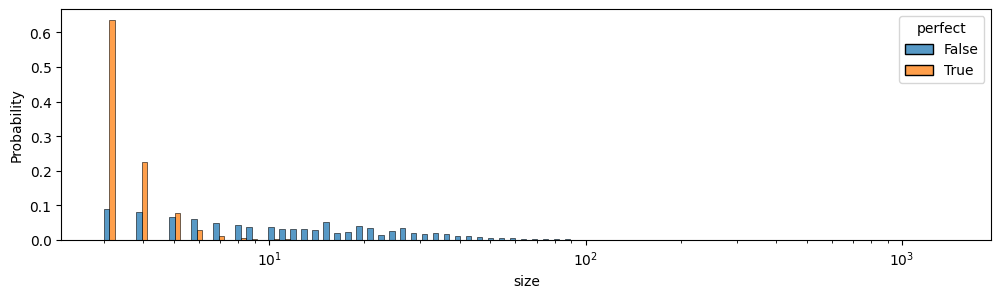

In [20]:
df_var["perfect"] = df_var["corr"] == 1
plt.figure(figsize=(12, 3))
sns.histplot(
    df_var,
    x="size",
    hue="perfect",
    multiple="dodge",
    stat="probability",
    common_norm=False,
    log_scale=True,
)